In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
df = pd.read_csv(r'C:\Users\user\OneDrive\wasimansari-iitm\git\Quora-duplicates\quora_question.csv')
# df = df.head(100000) # Select only the first 100,000 rows
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


# Primary EDA

In [3]:
df.shape

(404351, 6)

In [4]:
df['id'].nunique()

404351

In [5]:
df['is_duplicate'].value_counts()

is_duplicate
0    255045
1    149306
Name: count, dtype: int64

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

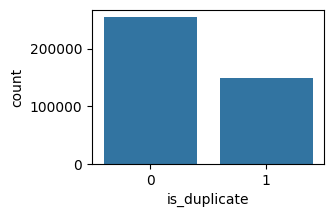

In [7]:
plt.figure(figsize=(3, 2))
sns.countplot(x = df['is_duplicate'])
plt.show()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404351 non-null  int64 
 1   qid1          404351 non-null  int64 
 2   qid2          404351 non-null  int64 
 3   question1     404350 non-null  object
 4   question2     404349 non-null  object
 5   is_duplicate  404351 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [9]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [10]:
df = df.dropna(axis = 0)

In [11]:
df.duplicated().sum()

0

In [12]:
qid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print("Unique question IDs from both qid1 and qid2:", np.unique(qid).shape[0])

Unique question IDs from both qid1 and qid2: 789795


In [13]:
print('Number of question IDs getting repeated:', qid[qid.duplicated()].nunique())

Number of question IDs getting repeated: 13698


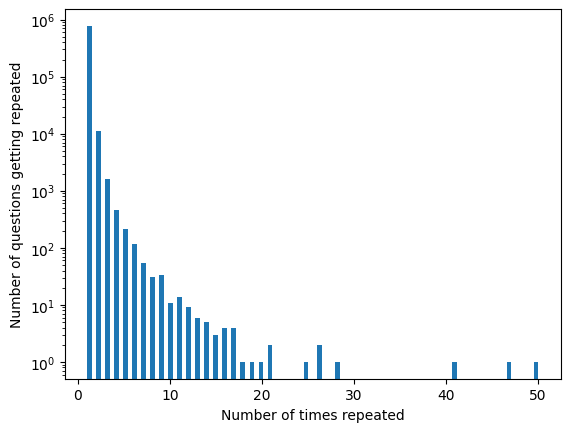

In [14]:
# Repeated questions histogram

plt.hist(qid.value_counts().values, bins=100)
plt.yscale('log')
plt.xlabel('Number of times repeated')
plt.ylabel('Number of questions getting repeated')
plt.xticks()
plt.show()

In [15]:
# Count '[math]' in both columns and sum
count_math = df['question1'].str.count(r'\[math\]').sum() + df['question2'].str.count(r'\[math\]').sum()

print('Total number of [math] occurences:', count_math)

Total number of [math] occurences: 1420


# Data Preprocessing

In [16]:
import re
from bs4 import BeautifulSoup

In [ ]:
def preprocess(q):

    # Lowercasing all the text
    q = str(q).lower().strip()
    
    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')
    
    # The pattern '[math]' appears around 900 times in the whole dataset.
    q = q.replace('[math]', '')
    
    # Replacing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)
    
    # Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3aList_of_English_contractions
    # https://stackoverflow.com/a/19794953
    contractions = { 
    "ain't": "am not",
    "aren't": "are not",
    "can't": "can not",
    "can't've": "can not have",
    "'cause": "because",
    "could've": "could have",
    "couldn't": "could not",
    "couldn't've": "could not have",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hadn't've": "had not have",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'd've": "he would have",
    "he'll": "he will",
    "he'll've": "he will have",
    "he's": "he is",
    "how'd": "how did",
    "how'd'y": "how do you",
    "how'll": "how will",
    "how's": "how is",
    "i'd": "i would",
    "i'd've": "i would have",
    "i'll": "i will",
    "i'll've": "i will have",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it'd": "it would",
    "it'd've": "it would have",
    "it'll": "it will",
    "it'll've": "it will have",
    "it's": "it is",
    "let's": "let us",
    "ma'am": "madam",
    "mayn't": "may not",
    "might've": "might have",
    "mightn't": "might not",
    "mightn't've": "might not have",
    "must've": "must have",
    "mustn't": "must not",
    "mustn't've": "must not have",
    "needn't": "need not",
    "needn't've": "need not have",
    "o'clock": "of the clock",
    "oughtn't": "ought not",
    "oughtn't've": "ought not have",
    "shan't": "shall not",
    "sha'n't": "shall not",
    "shan't've": "shall not have",
    "she'd": "she would",
    "she'd've": "she would have",
    "she'll": "she will",
    "she'll've": "she will have",
    "she's": "she is",
    "should've": "should have",
    "shouldn't": "should not",
    "shouldn't've": "should not have",
    "so've": "so have",
    "so's": "so as",
    "that'd": "that would",
    "that'd've": "that would have",
    "that's": "that is",
    "there'd": "there would",
    "there'd've": "there would have",
    "there's": "there is",
    "they'd": "they would",
    "they'd've": "they would have",
    "they'll": "they will",
    "they'll've": "they will have",
    "they're": "they are",
    "they've": "they have",
    "to've": "to have",
    "wasn't": "was not",
    "we'd": "we would",
    "we'd've": "we would have",
    "we'll": "we will",
    "we'll've": "we will have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what'll": "what will",
    "what'll've": "what will have",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "when's": "when is",
    "when've": "when have",
    "where'd": "where did",
    "where's": "where is",
    "where've": "where have",
    "who'll": "who will",
    "who'll've": "who will have",
    "who's": "who is",
    "who've": "who have",
    "why's": "why is",
    "why've": "why have",
    "will've": "will have",
    "won't": "will not",
    "won't've": "will not have",
    "would've": "would have",
    "wouldn't": "would not",
    "wouldn't've": "would not have",
    "y'all": "you all",
    "y'all'd": "you all would",
    "y'all'd've": "you all would have",
    "y'all're": "you all are",
    "y'all've": "you all have",
    "you'd": "you would",
    "you'd've": "you would have",
    "you'll": "you will",
    "you'll've": "you will have",
    "you're": "you are",
    "you've": "you have"
    }

    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")
    
    # Removing HTML tags
    q = BeautifulSoup(q)
    q = q.get_text()
    
    # Remove punctuations
    pattern = re.compile(r'\W')
    q = re.sub(pattern, ' ', q).strip()

    
    return q

<>:166: SyntaxWarning: invalid escape sequence '\W'
<>:166: SyntaxWarning: invalid escape sequence '\W'
C:\Users\user\AppData\Local\Temp\ipykernel_19028\2835538485.py:166: SyntaxWarning: invalid escape sequence '\W'
  pattern = re.compile('\W')


In [18]:
preprocess("I've already! wasn't <b>done</b>?")

'i have already  was not done'

In [19]:
df['question1'] = df['question1'].apply(preprocess)
df['question2'] = df['question2'].apply(preprocess)

In [20]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0


## Feature Engineering

In [21]:
# Length of characters (Alphabets)
df['q1_len'] = df['question1'].str.len()
df['q2_len'] = df['question2'].str.len()

In [22]:
# Number of words in the string
df['q1_num_words'] = df['question1'].str.split().str.len()
df['q2_num_words'] = df['question2'].str.split().str.len()

In [23]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,10,15
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,11,12
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,13,7


In [24]:
# Finding common words

# Step 1: Clean and split text
q1_words = df['question1'].str.lower().str.split()
q2_words = df['question2'].str.lower().str.split()

# Step 2: Turn into sets
q1_sets = q1_words.apply(set)
q2_sets = q2_words.apply(set)

# Step 3: Find intersections and count common words
df['common_word_count'] = q1_sets.combine(q2_sets, lambda a, b: len(a & b))

In [25]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_word_count
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,11
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,10,15,7
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,4
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,11,12,0
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,13,7,4


In [26]:
df['word_share'] = round(df['common_word_count']/(df['q1_num_words'] + df['q2_num_words']), 2)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_word_count,word_share
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,11,0.42
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,10,15,7,0.28
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,4,0.17
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,11,12,0,0.00
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,13,7,4,0.20


## Advanced Feature Engineering

In [27]:
# Advanced Features
from nltk.corpus import stopwords

def fetch_token_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    SAFE_DIV = 0.0001 

    STOP_WORDS = stopwords.words("english")
    
    token_features = [0.0]*8
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])
    
    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])
    
    # Get the common non-stopwords from Question pair
    common_wrd_count = len(q1_words.intersection(q2_words))
    
    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))
    
    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))
    
    
    token_features[0] = common_wrd_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_wrd_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    
    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
    
    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    
    return token_features

In [28]:
token_features = df.apply(fetch_token_features, axis=1)

df["cwc_min"]       = list(map(lambda x: x[0], token_features))
df["cwc_max"]       = list(map(lambda x: x[1], token_features))
df["csc_min"]       = list(map(lambda x: x[2], token_features))
df["csc_max"]       = list(map(lambda x: x[3], token_features))
df["ctc_min"]       = list(map(lambda x: x[4], token_features))
df["ctc_max"]       = list(map(lambda x: x[5], token_features))
df["last_word_eq"]  = list(map(lambda x: x[6], token_features))
df["first_word_eq"] = list(map(lambda x: x[7], token_features))

In [29]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_word_count,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,11,0.42,0.999980,0.833319,0.999983,0.999983,0.916659,0.785709,0.0,1.0
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,10,15,7,0.28,0.799984,0.399996,0.749981,0.599988,0.699993,0.466664,0.0,1.0
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,4,0.17,0.399992,0.333328,0.399992,0.249997,0.399996,0.285712,0.0,1.0
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,11,12,0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,13,7,4,0.20,0.399992,0.199998,0.999950,0.666644,0.571420,0.307690,0.0,1.0


In [30]:
!pip install distance

In [31]:
import distance

def fetch_length_features(row):
    q1 = row['question1']
    q2 = row['question2']
    
    length_features = [0.0]*3
    
    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    
    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    
    # Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens)) / 2
    
    # Get longest common substring(s)
    strs = list(distance.lcsubstrings(q1, q2))
    
    # Check if there are any common substrings
    if strs:
        length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    else:
        length_features[2] = 0.0  # If no common substrings, set it to 0
    
    return length_features

In [32]:
length_features = df.apply(fetch_length_features, axis=1)

df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
df['mean_len'] = list(map(lambda x: x[1], length_features))
df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [33]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [34]:
# Fuzzy Features
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    fuzzy_features = [0.0]*4
    
    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [35]:
fuzzy_features = df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
df['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))

In [36]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0,65,56,14,12,...,0.785709,0.0,1.0,2.0,13.0,0.982456,93,100,93,100
1,1,3,4,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...,0,50,87,10,15,...,0.466664,0.0,1.0,5.0,12.5,0.588235,66,74,63,86
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0,72,58,14,10,...,0.285712,0.0,1.0,4.0,12.0,0.169492,43,46,63,63
3,3,7,8,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...,0,49,58,11,12,...,0.000000,0.0,0.0,1.0,11.5,0.040000,9,11,25,28
4,4,9,10,which one dissolve in water quikly sugar salt...,which fish would survive in salt water,0,75,38,13,7,...,0.307690,0.0,1.0,6.0,10.0,0.153846,35,55,47,67


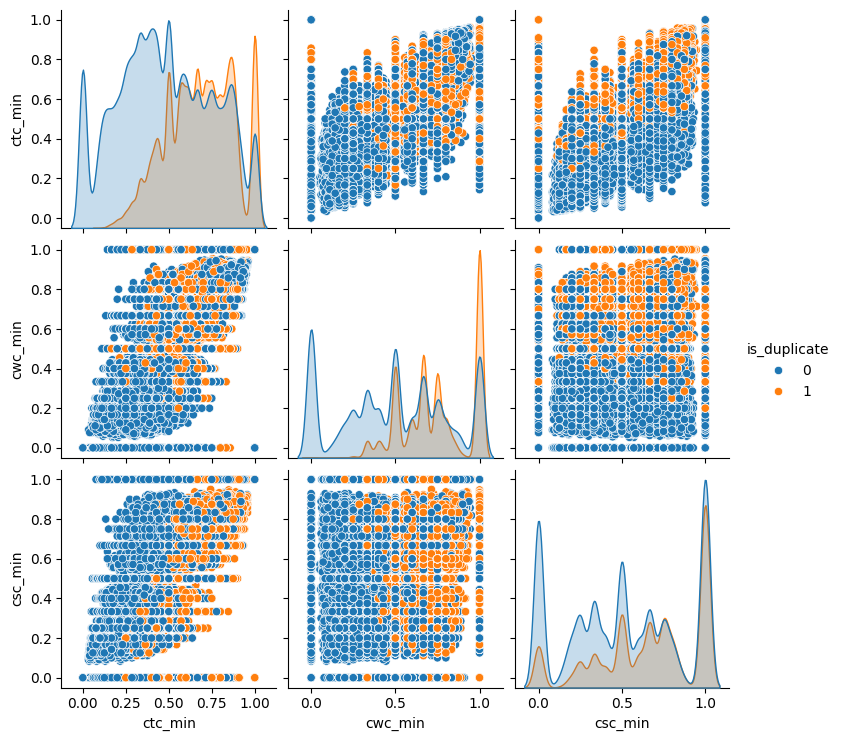

In [37]:
sns.pairplot(df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']],hue='is_duplicate')
plt.show()

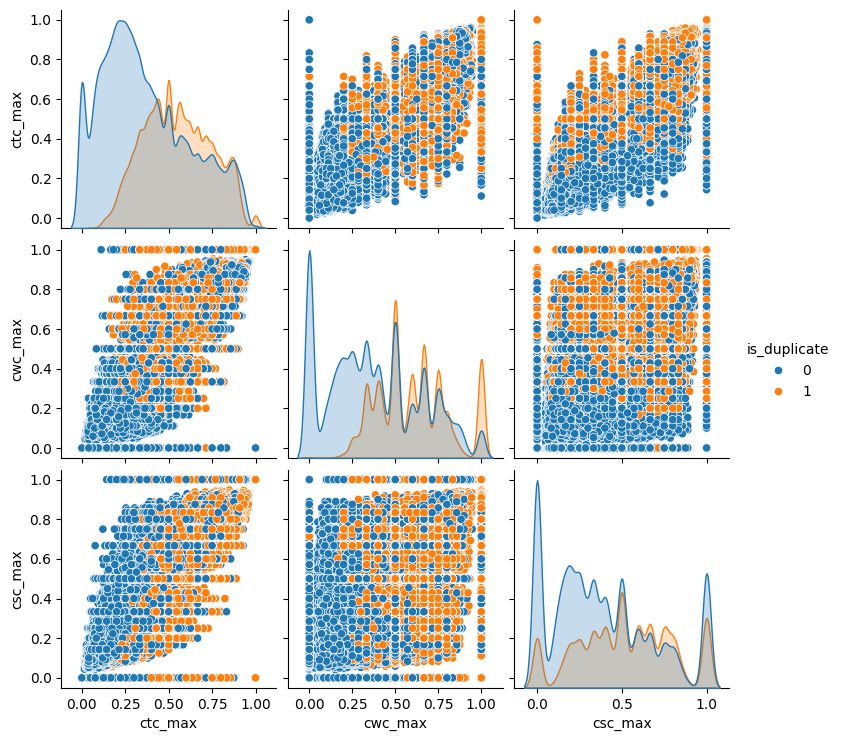

In [38]:
sns.pairplot(df[['ctc_max', 'cwc_max', 'csc_max', 'is_duplicate']],hue='is_duplicate')
plt.show()

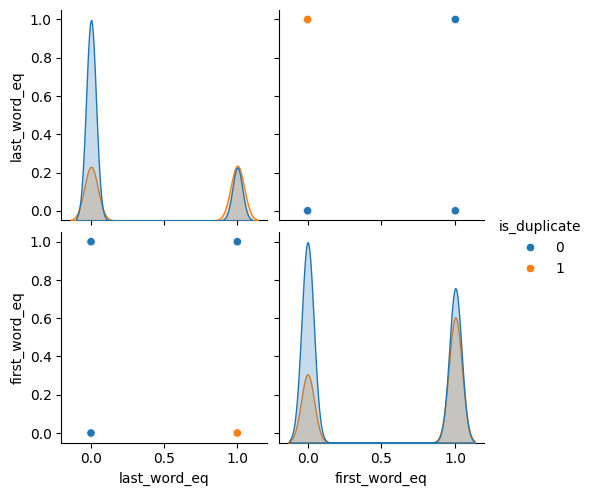

In [39]:
sns.pairplot(df[['last_word_eq', 'first_word_eq', 'is_duplicate']],hue='is_duplicate')
plt.show()

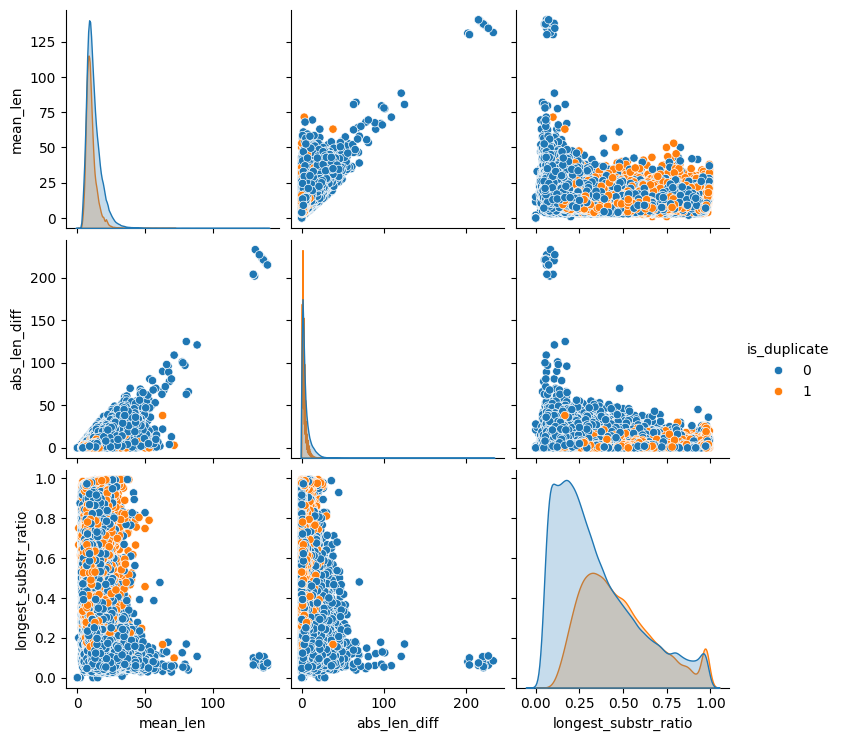

In [40]:
sns.pairplot(df[['mean_len', 'abs_len_diff','longest_substr_ratio', 'is_duplicate']],hue='is_duplicate')
plt.show()

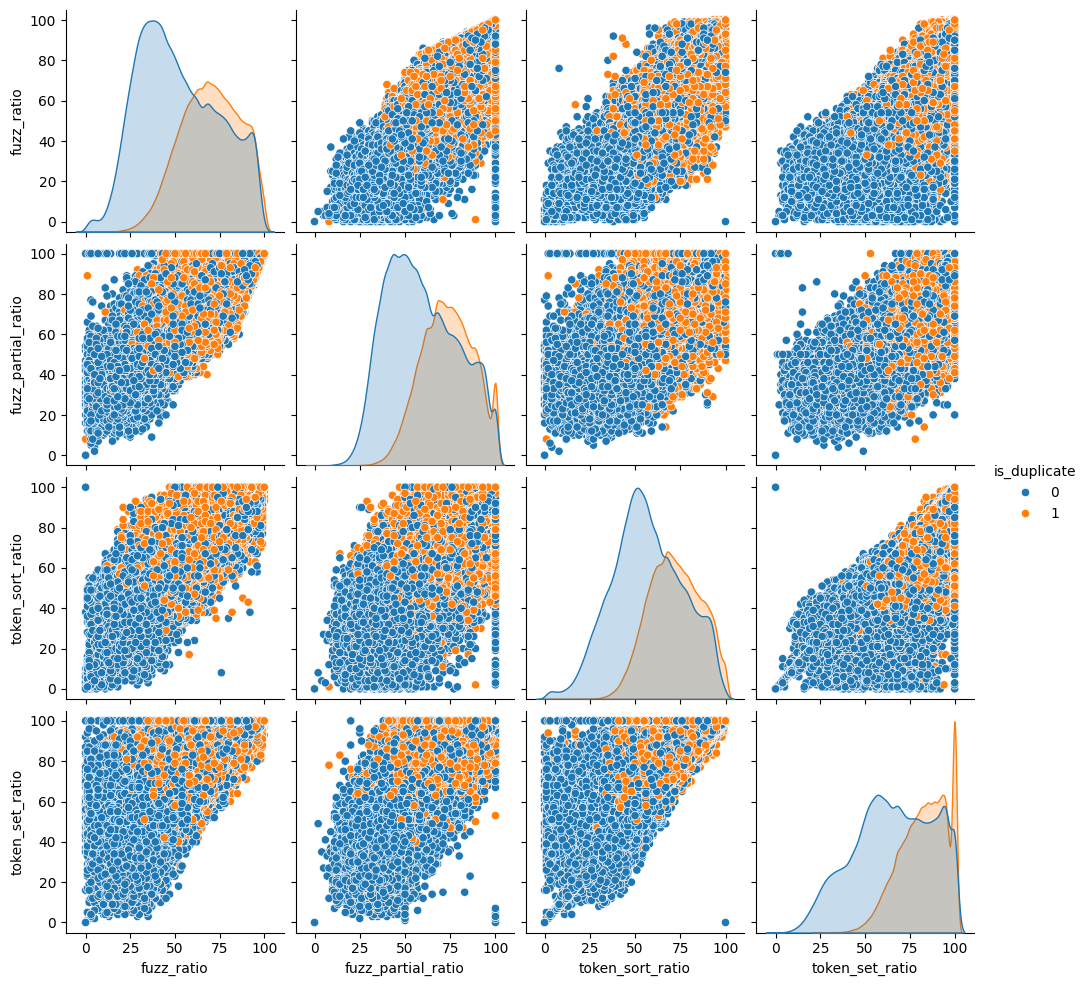

In [41]:
sns.pairplot(df[['fuzz_ratio', 'fuzz_partial_ratio','token_sort_ratio','token_set_ratio', 'is_duplicate']],hue='is_duplicate')
plt.show()

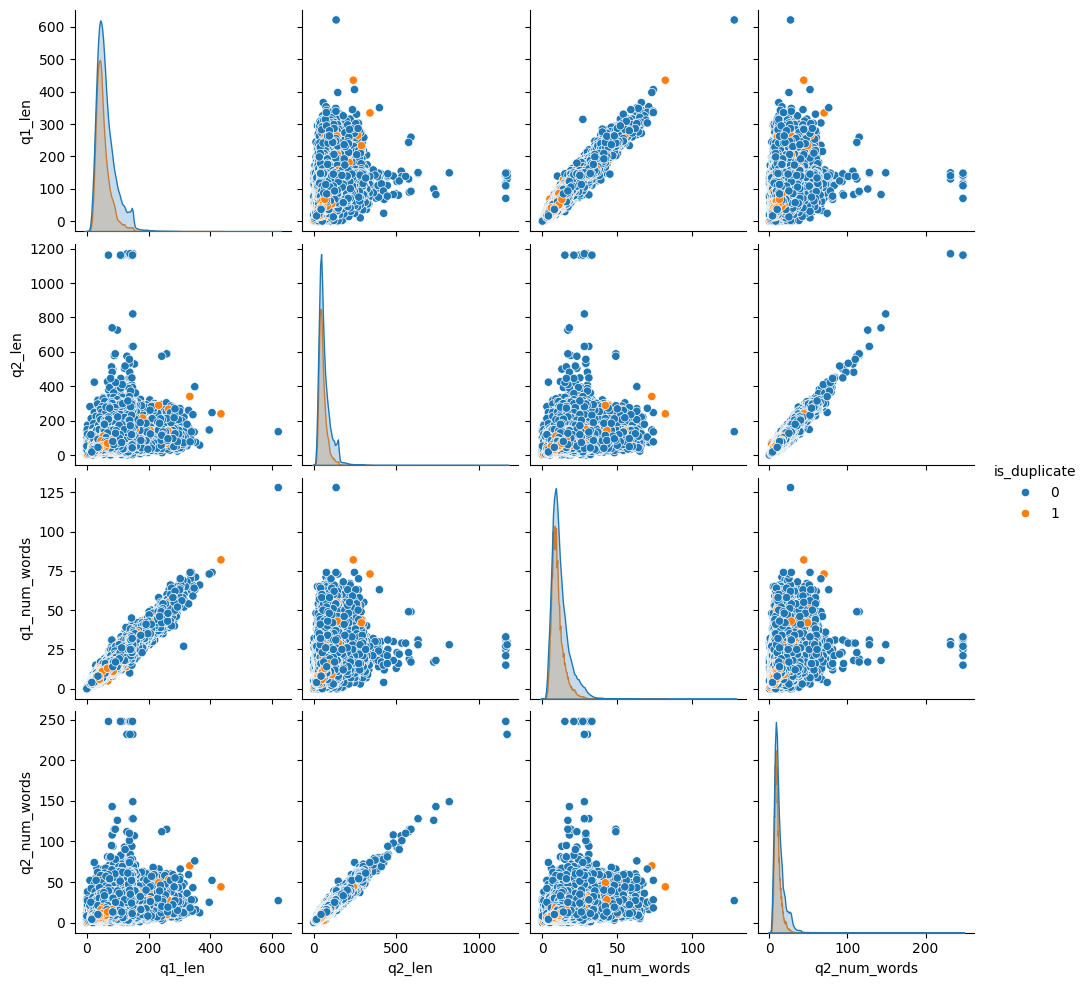

In [42]:
sns.pairplot(df[['q1_len', 'q2_len','q1_num_words','q2_num_words', 'is_duplicate']],hue='is_duplicate')
plt.show()

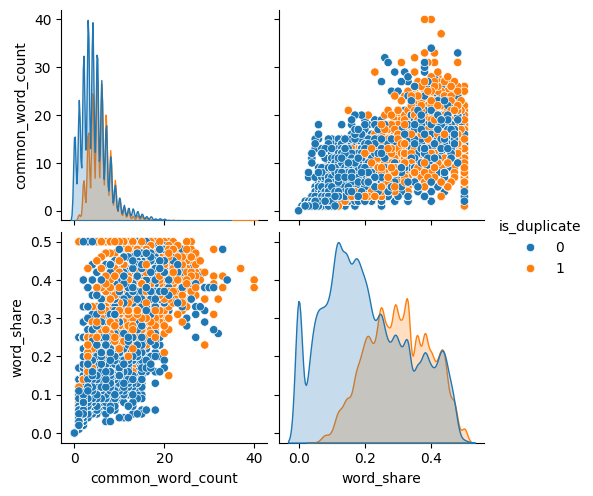

In [43]:
sns.pairplot(df[['common_word_count', 'word_share', 'is_duplicate']],hue='is_duplicate')
plt.show()

In [44]:
# from sklearn.preprocessing import MinMaxScaler

# X_t = MinMaxScaler().fit_transform(df[['cwc_min', 'cwc_max', 'csc_min', 'csc_max' , 'ctc_min' , 'ctc_max' , 'last_word_eq', 'first_word_eq' , 'abs_len_diff' , 'mean_len' , 'token_set_ratio' , 'token_sort_ratio' ,  'fuzz_ratio' , 'fuzz_partial_ratio' , 'longest_substr_ratio']])
# y_t = df['is_duplicate'].values

In [45]:
# from sklearn.manifold import TSNE

# # Randomly sample a subset of data with a fixed seed
# np.random.seed(42)  # Fixing the seed for reproducibility
# random_indices = np.random.choice(X_t.shape[0], size=30000, replace=False)  # Random sample without replacement
# X_subset = X_t[random_indices]

# # Apply t-SNE
# tsne = TSNE(n_components=2, random_state=42)
# X_tsne = tsne.fit_transform(X_subset)

# # Create DataFrame for plotting
# x_df = pd.DataFrame({'x': X_tsne[:, 0], 'y': X_tsne[:, 1], 'label': y[random_indices]})

# # Draw the plot
# sns.lmplot(data=x_df, x='x', y='y', hue='label', fit_reg=False, height=8, palette="Set1", markers=['s', 'o'])
# plt.show()

In [46]:
ques_df = df[['question1','question2']]
ques_df.head()

,question1,question2
0,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...
1,what is the story of kohinoor koh i noor dia...,what would happen if the indian government sto...
2,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...
3,why am i mentally very lonely how can i solve it,find the remainder when 23 24 math is divi...
4,which one dissolve in water quikly sugar salt...,which fish would survive in salt water


In [47]:
final_df = df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(404348, 22)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_word_count,word_share,cwc_min,cwc_max,csc_min,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0,65,56,14,12,11,0.42,0.999980,0.833319,0.999983,...,0.785709,0.0,1.0,2.0,13.0,0.982456,93,100,93,100
1,0,50,87,10,15,7,0.28,0.799984,0.399996,0.749981,...,0.466664,0.0,1.0,5.0,12.5,0.588235,66,74,63,86
2,0,72,58,14,10,4,0.17,0.399992,0.333328,0.399992,...,0.285712,0.0,1.0,4.0,12.0,0.169492,43,46,63,63
3,0,49,58,11,12,0,0.00,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,1.0,11.5,0.040000,9,11,25,28
4,0,75,38,13,7,4,0.20,0.399992,0.199998,0.999950,...,0.307690,0.0,1.0,6.0,10.0,0.153846,35,55,47,67


In [48]:
y = final_df['is_duplicate']
final_df = final_df.drop(columns=['is_duplicate'])

In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

final_scaled_array = scaler.fit_transform(final_df)
final_df = pd.DataFrame(final_scaled_array, columns=final_df.columns)
final_df.head()

,q1_len,q2_len,q1_num_words,q2_num_words,common_word_count,word_share,cwc_min,cwc_max,csc_min,csc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
0,0.104670,0.047863,0.109375,0.048387,0.275,0.84,0.999984,0.833323,0.999988,0.999988,...,0.785712,0.0,1.0,0.008584,0.092527,0.988235,0.93,1.00,0.93,1.00
1,0.080515,0.074359,0.078125,0.060484,0.175,0.56,0.799987,0.399998,0.749985,0.599991,...,0.466665,0.0,1.0,0.021459,0.088968,0.591696,0.66,0.74,0.63,0.86
2,0.115942,0.049573,0.109375,0.040323,0.100,0.34,0.399994,0.333329,0.399994,0.249998,...,0.285713,0.0,1.0,0.017167,0.085409,0.170489,0.43,0.46,0.63,0.63
3,0.078905,0.049573,0.085938,0.048387,0.000,0.00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.004292,0.081851,0.040235,0.09,0.11,0.25,0.28
4,0.120773,0.032479,0.101562,0.028226,0.100,0.40,0.399994,0.199999,0.999955,0.666648,...,0.307691,0.0,1.0,0.025751,0.071174,0.154751,0.35,0.55,0.47,0.67


In [50]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

# Download NLTK resources
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...


True

In [51]:
# Define a function to tokenize and lemmatize text
def tokenize_and_lemmatize(text):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text.lower())  # Tokenize and lowercase
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens if token.isalpha()]  # Remove non-alphabetic tokens
    return ' '.join(lemmatized_tokens)  # Join back into a cleaned string

# Step 1: Merge questions into a single list
questions = list(ques_df['question1']) + list(ques_df['question2'])

# Step 2: Preprocess each question (tokenize + lemmatize)
cleaned_questions = Parallel(n_jobs=-1)(delayed(tokenize_and_lemmatize)(q) for q in questions)

print('Text Lemmatized')

Text Lemmatized


In [52]:
# def find_best_max_features(cleaned_questions, ques_df, final_df, y, max_features_list):
#     results = []
    
#     for max_feat in max_features_list:
#         print(f"\n▶ Testing max_features={max_feat}...")
        
#         # Step 1: Vectorize
#         tfidf = TfidfVectorizer(max_features=max_feat, stop_words='english')
#         X = tfidf.fit_transform(cleaned_questions)
#         feature_names = tfidf.get_feature_names_out()

#         # Step 2: Split and label
#         q1_arr, q2_arr = np.vsplit(X.toarray(), 2)
#         q1_feature_names = [f'q1_{feat}' for feat in feature_names]
#         q2_feature_names = [f'q2_{feat}' for feat in feature_names]

#         # Step 3: Create minimal DataFrame and combine
#         temp_df = pd.concat([
#             pd.DataFrame(q1_arr, index=ques_df.index, columns=q1_feature_names),
#             pd.DataFrame(q2_arr, index=ques_df.index, columns=q2_feature_names)
#         ], axis=1)
        
#         X_final = pd.concat([final_df, temp_df], axis=1)
        
#         # Step 4: Train/Test split
#         X_train, X_test, y_train, y_test = train_test_split(
#             X_final, y, test_size=0.2, stratify=y, random_state=1
#         )

#         # Step 5: Train model
#         xgb = XGBClassifier(random_state=42, n_jobs=-1, verbosity=0)
#         xgb.fit(X_train, y_train)

#         # Step 6: Predict and evaluate
#         y_pred = xgb.predict(X_test)
#         acc = accuracy_score(y_test, y_pred)
#         cm = confusion_matrix(y_test, y_pred)
#         cr = classification_report(y_test, y_pred)

#         print(f"✅ Accuracy: {acc:.4f}")
#         print(f"🧩 Confusion Matrix:\n{cm}")
#         print(f"📄 Classification Report:\n{cr}")

#         results.append((max_feat, acc))

#         # ✨ Explicitly delete heavy objects to free memory
#         del tfidf, X, q1_arr, q2_arr, temp_df, X_final, X_train, X_test, y_train, y_test, xgb, y_pred, cm, cr

#     return pd.DataFrame(results, columns=['max_features', 'accuracy']).sort_values(by='accuracy', ascending=False).reset_index(drop=True)

In [53]:
# max_features_list = [2000, 2250, 2500, 2750, 3000]
# results_df = find_best_max_features(cleaned_questions, ques_df, final_df, y, max_features_list)

# print("\nFinal Results:")
# results_df

In [54]:
# from gensim.models import Word2Vec
# from sklearn.model_selection import StratifiedKFold
# import gc

# def evaluate_word2vec(cleaned_questions, ques_df, final_df, y, dimensions=[150, 200, 250, 300], folds=4):

#     results = []
#     sentences = [q.split() for q in cleaned_questions]

#     for dim in dimensions:
#         print(f"\n▶ Testing Word2Vec with vector_size={dim}...")

#         # Train Word2Vec
#         model = Word2Vec(sentences=sentences, vector_size=dim, window=5, min_count=1, workers=1, sg=1, seed=42)
#         wv = model.wv
#         del model
#         gc.collect()

#         # Split into question1 and question2
#         half = len(cleaned_questions) // 2
#         q1 = cleaned_questions[:half]
#         q2 = cleaned_questions[half:]

#         def avg_w2v(text):
#             words = text.split()
#             vectors = [wv[w] for w in words if w in wv]
#             return np.mean(vectors, axis=0) if vectors else np.zeros(dim)

#         q1_vecs = np.array([avg_w2v(q) for q in q1], dtype=np.float32)
#         q2_vecs = np.array([avg_w2v(q) for q in q2], dtype=np.float32)

#         X_vec = np.hstack((q1_vecs, q2_vecs))
#         X_final = pd.concat([final_df.reset_index(drop=True), pd.DataFrame(X_vec)], axis=1)

#         skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
#         accs_xgb = []
#         precisions = []
#         recalls = []

#         print("\n📁 Cross-validation Results:")
#         for fold, (train_idx, test_idx) in enumerate(skf.split(X_final, y)):
#             X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
#             y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

#             print(f"\n📂 Fold {fold + 1}:")

#             xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
#             xgb.fit(X_train, y_train)

#             y_pred = xgb.predict(X_test)
#             acc = accuracy_score(y_test, y_pred)
#             accs_xgb.append(acc)

#             report = classification_report(y_test, y_pred, output_dict=True)
#             precisions.append(report['macro avg']['precision'])
#             recalls.append(report['macro avg']['recall'])

#             print(f"🔷 XGBoost Accuracy: {acc:.4f}")
#             print("🔷 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
#             print("🔷 Classification Report:\n", classification_report(y_test, y_pred, digits=4))

#         mean_acc_xgb = np.mean(accs_xgb)
#         mean_precision = np.mean(precisions)
#         mean_recall = np.mean(recalls)

#         print(f"\n✅ Mean Accuracy (XGBoost): {mean_acc_xgb:.4f}")
#         print(f"✅ Mean Macro Precision: {mean_precision:.4f}")
#         print(f"✅ Mean Macro Recall: {mean_recall:.4f}")

#         results.append({
#             'vector_size': dim,
#             'xgboost_accuracy': mean_acc_xgb,
#             'macro_precision': mean_precision,
#             'macro_recall': mean_recall
#         })

#         # Cleanup
#         del wv, q1_vecs, q2_vecs, X_vec, X_final, xgb
#         gc.collect()

#     results_df = pd.DataFrame(results).sort_values(by='xgboost_accuracy', ascending=False)
#     print("\n📊 Final Summary:")
#     print(results_df)

#     return results_df

In [55]:
# results = evaluate_word2vec(cleaned_questions, ques_df, final_df, y, 
#                             dimensions=[150, 200, 250, 300], folds=4)

In [56]:
import gc
import pickle
from gensim.models import Word2Vec

def prepare_training_dataset(cleaned_questions, final_df, y, vector_size=150, export_path="word2vec_model.pkl"):
    print(f"\n🧠 Building Word2Vec with vector_size={vector_size} for final training...")

    # Train Word2Vec on all sentences
    sentences = [q.split() for q in cleaned_questions]
    word2vec = Word2Vec(sentences=sentences, vector_size=vector_size, window=5, min_count=1, workers=1, sg=1, seed=42)

    # ✅ Save model using pickle
    with open(export_path, "wb") as f:
        pickle.dump(word2vec, f)

    wv = word2vec.wv
    del word2vec
    gc.collect()

    # Split cleaned_questions into question1 and question2
    half = len(cleaned_questions) // 2
    q1 = cleaned_questions[:half]
    q2 = cleaned_questions[half:]

    def avg_w2v(text):
        words = text.split()
        vectors = [wv[w] for w in words if w in wv]
        return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

    # Compute embeddings for both question parts
    q1_vecs = np.array([avg_w2v(q) for q in q1], dtype=np.float32)
    q2_vecs = np.array([avg_w2v(q) for q in q2], dtype=np.float32)

    # Concatenate q1 and q2 embeddings
    X_vec = np.hstack((q1_vecs, q2_vecs))
    X_final = pd.concat([final_df.reset_index(drop=True), pd.DataFrame(X_vec)], axis=1)

    # Cleanup
    del wv, q1_vecs, q2_vecs, X_vec
    gc.collect()

    print(f"✅ Final training set shape: {X_final.shape}")
    print(f"📦 Word2Vec model saved to: {export_path}")
    return X_final, y


In [59]:
X_final, y_final = prepare_training_dataset(cleaned_questions, final_df, y)


🧠 Building Word2Vec with vector_size=150 for final training...
✅ Final training set shape: (404348, 321)
📦 Word2Vec model saved to: word2vec_model.pkl


In [60]:
import time
start = time.time()

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, stratify=y, random_state=42)

# Train XGBoost
xgb_model = XGBClassifier(colsample_bytree = 0.6028265220878869, gamma = 0.006918727512424727, 
                             learning_rate = 0.16743239807751675, max_depth = 9, n_estimators = 269,
                             reg_alpha = 0.04666566321361543, reg_lambda = 0.9737555188414592,
                             scale_pos_weight = 1.6638567021515211, subsample = 0.6362425738131283, 
                             random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict and directly print evaluations
print(f"\n🎯 XGBoost Accuracy: {accuracy_score(y_test, xgb_model.predict(X_test)):.5f}")
print("🧩 Confusion Matrix:")
print(confusion_matrix(y_test, xgb_model.predict(X_test)))
print("📄 Classification Report:")
print(classification_report(y_test, xgb_model.predict(X_test), digits=4))

end = time.time()
print(f"Elapsed time: {end - start:.3f} seconds")

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:45:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🎯 XGBoost Accuracy: 0.84541
🧩 Confusion Matrix:
[[43353  7656]
 [ 4846 25015]]
📄 Classification Report:
              precision    recall  f1-score   support

           0     0.8995    0.8499    0.8740     51009
           1     0.7657    0.8377    0.8001     29861

    accuracy                         0.8454     80870
   macro avg     0.8326    0.8438    0.8370     80870
weighted avg     0.8501    0.8454    0.8467     80870

Elapsed time: 214.428 seconds


In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint, uniform
# start = time.time()

# # Define parameter grid
# param_dist = {
#     'n_estimators': randint(100, 400),
#     'max_depth': randint(3, 10),
#     'learning_rate': uniform(0.01, 0.3),
#     'subsample': uniform(0.6, 0.4),
#     'colsample_bytree': uniform(0.6, 0.4),
#     'gamma': uniform(0, 0.3),
#     'reg_lambda': uniform(0, 1),
#     'reg_alpha': uniform(0, 1),
#     'scale_pos_weight': uniform(0.5, 5)  # Adjust this based on class imbalance ratio
# }

# # Initialize model
# xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# # Randomized Search CV
# rs = RandomizedSearchCV(
#     xgb,
#     param_distributions=param_dist,
#     n_iter=5,
#     cv=4,
#     scoring='accuracy',
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# # Fit
# rs.fit(X_final, y_final)

# # Output best results
# print("\n🔍 Best Parameters Found:")
# print(rs.best_params_)

# print(f"\n✅ Best CV Accuracy: {rs.best_score_:.5f}")

# best_xgb = rs.best_estimator_
# best_xgb.fit(X_train, y_train)

# print(f"\n🎯 XGBoost Accuracy: {accuracy_score(y_test, best_xgb.predict(X_test)):.5f}")
# print("🧩 Confusion Matrix:")
# print(confusion_matrix(y_test, best_xgb.predict(X_test)))
# print("📄 Classification Report:")
# print(classification_report(y_test, best_xgb.predict(X_test), digits=4))

# end = time.time()
# print(f"Elapsed time: {end - start:.3f} seconds")

📈 Generating learning curve for XGBoost...
⏱️  Time taken: 1405.02 seconds


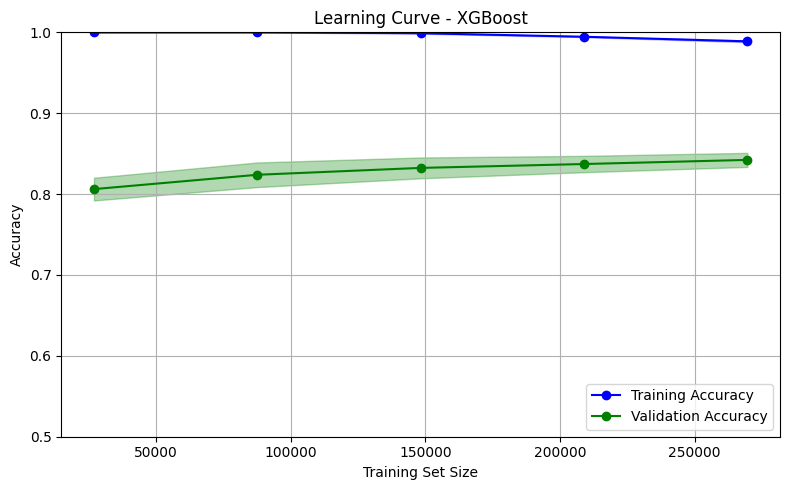

In [61]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold
import time

# Your tuned XGBoost model
xgb_model = XGBClassifier(
    colsample_bytree=0.6028265220878869,
    gamma=0.006918727512424727,
    learning_rate=0.16743239807751675,
    max_depth=9,
    n_estimators=269,
    reg_alpha=0.04666566321361543,
    reg_lambda=0.9737555188414592,
    scale_pos_weight=1.6638567021515211,
    subsample=0.6362425738131283,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Function to plot learning curve for the given estimator
def plot_learning_curve(estimator, X, y):
    train_sizes = np.linspace(0.1, 1.0, 5)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    print("📈 Generating learning curve for XGBoost...")
    start = time.time()
    
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )

    print(f"⏱️  Time taken: {time.time() - start:.2f} seconds")

    # Mean and std
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes_abs, train_mean, 'o-', color='blue', label='Training Accuracy')
    plt.fill_between(train_sizes_abs, train_mean - (10*train_std), train_mean + (10*train_std), alpha=0.3, color='blue')

    plt.plot(train_sizes_abs, val_mean, 'o-', color='green', label='Validation Accuracy')
    plt.fill_between(train_sizes_abs, val_mean - (10*val_std), val_mean + (10*val_std), alpha=0.3, color='green')

    plt.title("Learning Curve - XGBoost")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.ylim(0.5, 1.0)
    plt.grid(True)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

plot_learning_curve(xgb_model, X_final, y_final)

In [65]:
# Save the XGBoost model
xgb_model.fit(X_train, y_train)
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Save the fitted MinMaxScaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:36:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [68]:
import helper
from bs4 import BeautifulSoup

def preprocess_with_lxml(q):
    q = helper.preprocess.__globals__["preprocess"](q)
    # Patch: always use features="lxml"
    if isinstance(q, BeautifulSoup):
        return q.get_text()
    return BeautifulSoup(q, features="lxml").get_text()

helper.preprocess = preprocess_with_lxml

In [1]:
import pickle
import numpy as np
from helper import query_point_creator
from gensim.models import Word2Vec

# Load the saved XGBoost model and scaler
with open("xgb_model.pkl", "rb") as f:
    xgb_model = pickle.load(f)
with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open("word2vec_model.pkl", "rb") as f:
    w2v_model = pickle.load(f)
wv = w2v_model.wv

# Example questions
q1 = "What is the ideal city to visit in India for holidays?"
q2 = "Which is the best tourist destination in india?"

# Create the feature vector (shape: (321,))
features = query_point_creator(q1, q2, wv=wv, scaler=scaler)

# Reshape for prediction (XGBoost expects 2D array)
features = features.reshape(1, -1)

# Make prediction
pred = xgb_model.predict(features)[0]
proba = xgb_model.predict_proba(features)[0][1]

# warnings.filterwarnings("ignore", message="X does not have valid feature names, but MinMaxScaler was fitted with feature names")
print(f"Prediction (1=duplicate, 0=not duplicate): {pred}")
print(f"Probability of being duplicate: {proba:.4f}")

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Prediction (1=duplicate, 0=not duplicate): 0
Probability of being duplicate: 0.0044
